# Quick-look for simulations

This notebook can be used to have a quicklook at the that product for the simulations.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib notebook

In [2]:
import os
import sys
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# PlatoSim libraries
from platosim.lightcurve import LightCurve
from platosim.matplotlibrc import setup_notebook
setup_notebook()

---
## Single mode
---

In [65]:
# path = '/lhome/nicholas/software/workdir/cs-binary/test_hdf5'
# filename = f"{path}/000000001/000000001_Ncam3.1_Q1.hdf5"
# filename = f"{path}/000000004/000000004_Ncam1.1_Q3.hdf5"

# path = '/lhome/nicholas/software/workdir/cs-planet/test_hdf5'
# filename = f"{path}/000000001/000000001_Ncam1.5_Q1.hdf5"

path = '/lhome/nicholas/software/workdir/cs-exomoon/test_hdf5'
filename = f"{path}/000000001/000000001_Ncam1.1_Q1.hdf5"

# Load a single mission quarter light curve
lc = LightCurve(filename, mode="single")
ds = lc.star()
ds

ID                     1
PIC        2707228000089
ra             93.000747
dec           -46.153593
mag                  8.5
group                  1
camera                 1
quarter                1
ccd                    4
xCCD         1814.610378
yCCD          2470.93383
rOA            11.635389
xFP            38.003191
yFP            33.962987
ncon                   0
SPR                  0.0
Name: 0, dtype: object

<IPython.core.display.Javascript object>


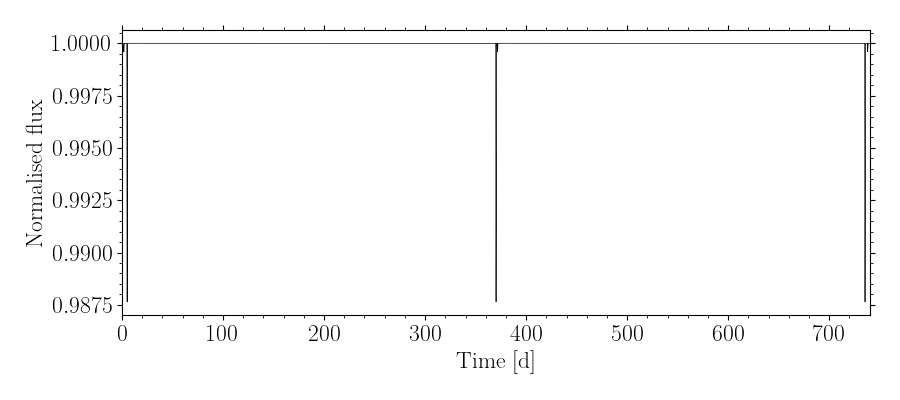

In [59]:
# Show in the injected variability
dv = lc.varsource()

fig, ax = plt.subplots(1, 1, figsize=(9,4))
ax.plot(dv.time/86400, dv.flux, 'k-', lw=0.5)
ax.set_xlabel('Time [d]')
ax.set_ylabel('Normalised flux')
ax.set_xlim(dv.time.min()/86400, dv.time.max()/86400)
plt.tight_layout();

<IPython.core.display.Javascript object>


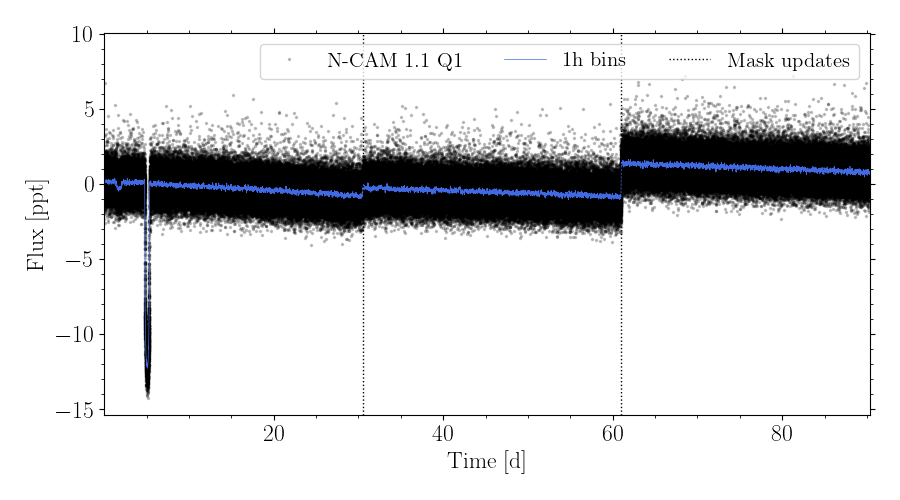

In [62]:
# Show a quarter light curve
lc.plot(flux_unit='ppt', median_filter=1, input_model=False, figsize=(9,5));

### *Test post-processing*

<IPython.core.display.Javascript object>


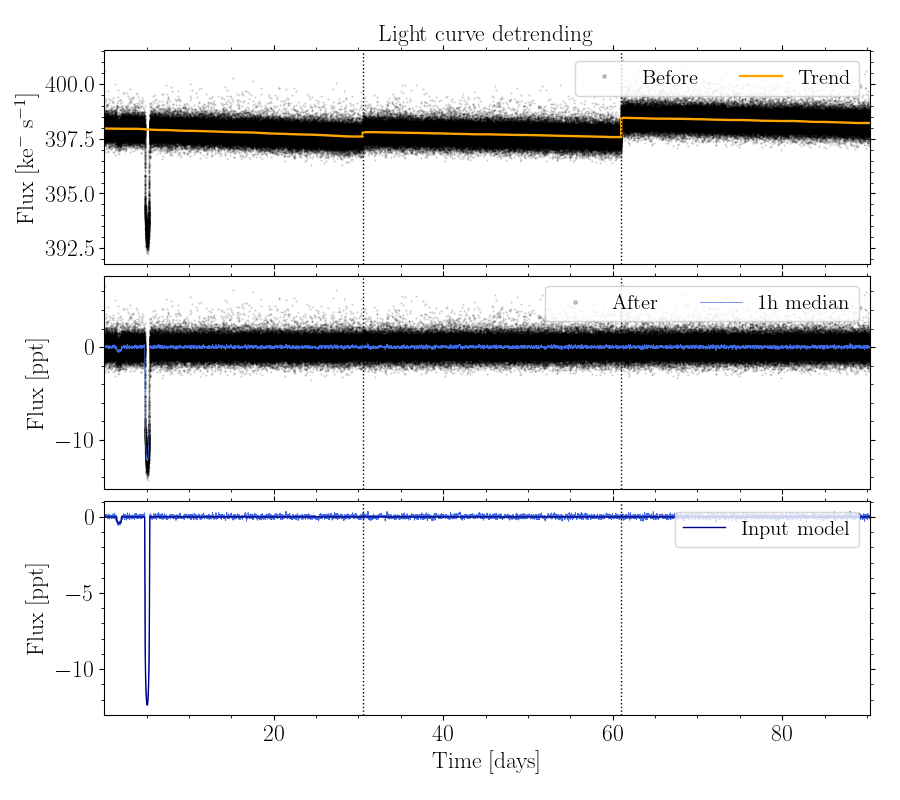

In [66]:
# df = lc.detrend(model='lowess', segments=True, replace=True, plot=True)
df = lc.detrend(model='wotan', segments=True, replace=True, plot=True)

<IPython.core.display.Javascript object>


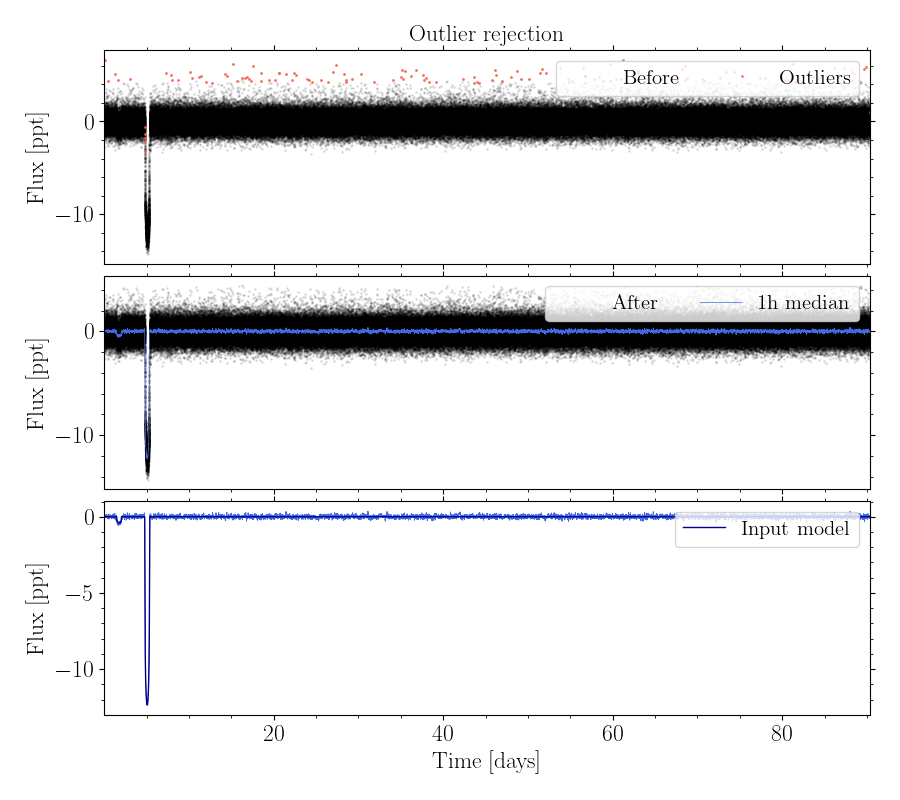

In [67]:
# Remove outliers (due to photon noise and cosmic ray hits)
df = lc.clip(model='wotan', magnitude=ds.mag, flux_unit='ppt', replace=True, plot=True)

In [184]:
# Stitch the segments (only needed if detrending leaves big jumps)
# df = lc.stitch(column='flux_detrend', method='lowess', gapsize=0.1, segment=5, plot=True)

---
## Multi mode
---

In [74]:
# path = '/lhome/nicholas/software/workdir/cs-binary/test_vsc/000000001'

# path = '/lhome/nicholas/software/workdir/cs-planet/tests_vsc/000000001'

path = '/lhome/nicholas/software/workdir/cs-exomoon/test_vsc'
star = '000000002'

# In multi mode we parse the entire directory of files
lcs = LightCurve(f'{path}/{star}', mode="multi")

In [83]:
lcs = LightCurve(f'{path}', mode="multi")

<bound method LightCurve.files of <platosim.lightcurve.LightCurve object at 0x7f4814251d90>>

In [63]:
lcs.unpack()

### *Use multi-mode as single-mode*

In [75]:
# Fetch files in folder
filenames = lcs.files(suffix='ftr')
filenames[:3]

['/lhome/nicholas/software/workdir/cs-exomoon/test_vsc/000000002/000000002_Ncam1.1_Q1.ftr',
 '/lhome/nicholas/software/workdir/cs-exomoon/test_vsc/000000002/000000002_Ncam1.1_Q2.ftr',
 '/lhome/nicholas/software/workdir/cs-exomoon/test_vsc/000000002/000000002_Ncam1.1_Q3.ftr']

In [76]:
# Again one can fetch the first light curve for this star
lc = LightCurve(filenames[0])
lc.data().head()

,time,flux
0,18.75,1.000658
1,43.75,0.999838
2,68.75,0.999355
3,93.75,1.000077
4,118.75,0.999925


### *Simulation statistics*

The `.table` files each contain a small overview of the specific simulation. It is much handier to have a single file to search information from, hence, we can merge to one single overview table as follows. It possible to remove the redundant `.table` files during the process using `clean=True`:

In [77]:
df = lcs.stat_sim_table(ofile=f'{path}/../table/lc_{star}.tab', clean=True)
df.head()

100%|██████████████████████████████████████████████████| 1/1 [00:00<00:00,  3.08


,ID,PIC,ra,dec,mag,group,camera,quarter,ccd,xCCD,yCCD,rOA,xFP,yFP,ncon,SPR
0,2,2763379000147,95.271476,-49.165609,8.5,1,1,1,4,1597.544244,3296.697700,8.712537,23.139441,30.055796,1,0.054770
1,2,2763379000147,95.271476,-49.165609,8.5,1,1,2,4,1829.704588,2903.057636,10.453630,30.224963,34.234683,1,0.052891
2,2,2763379000147,95.271476,-49.165609,8.5,1,1,3,4,1440.591138,2684.320149,10.009583,34.162237,27.230640,1,0.050120
3,2,2763379000147,95.271476,-49.165609,8.5,1,1,4,4,1212.277988,3078.666379,8.183523,27.064005,23.121004,1,0.053351
4,2,2763379000147,95.271476,-49.165609,8.5,1,1,5,4,1597.758034,3296.745504,8.713108,23.138581,30.059645,1,0.054894


### *View simulations*

In [78]:
fig, ax = lcs.plot_multi(suffix='ftr', group=1, camera=1, quarter=False, 
                         flux_median=144, alpha=0.1, figsize=(9,5))

<IPython.core.display.Javascript object>

In [79]:
lc = lcs.merge(suffix='ftr', binsize=1/6, flux_group_mean=True, flux_offset=True, 
               ofile=f'{path}/../final/lc_{star}.ftr')

Merging light curves:


100%|██████████████████████████████████████████████████| 192/192 [00:33<00:00,  


Sorting data after timings
Averaging data from same camera group
Binning data per 0.16666666666666666h
Corrrecting flux offset of -15.49819897272986 ppm
Done!


In [80]:
lc.plot(input_model=True, flux_unit='ppm', median_filter=1, alpha=0.1, figsize=(9,6));

<IPython.core.display.Javascript object>

---
## Final data products
---

<IPython.core.display.Javascript object>


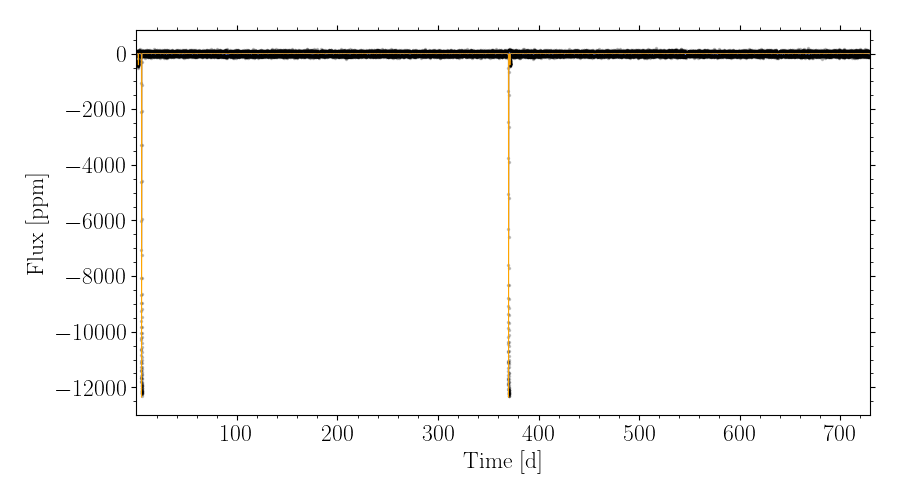

In [109]:
path = '/lhome/nicholas/software/workdir/cs-exomoon/finals'
star = 'mag085/lc_000000001.ftr'
# star = 'star5/lc_000000005.ftr'

# In multi mode we parse the entire directory of files
lc = LightCurve(f'{path}/{star}', mode="final")

# Introduce gaps from file
inputFileGap = '/lhome/nicholas/software/workdir/mocka/input/instrumentGAP.tab'
lc.gaps(inputFileGap, replace=True, plot=False);

# Show a quarter light curve
lc.plot(flux_unit='ppm', median_filter=1, input_model=True, legend=False, figsize=(9,5));

<IPython.core.display.Javascript object>


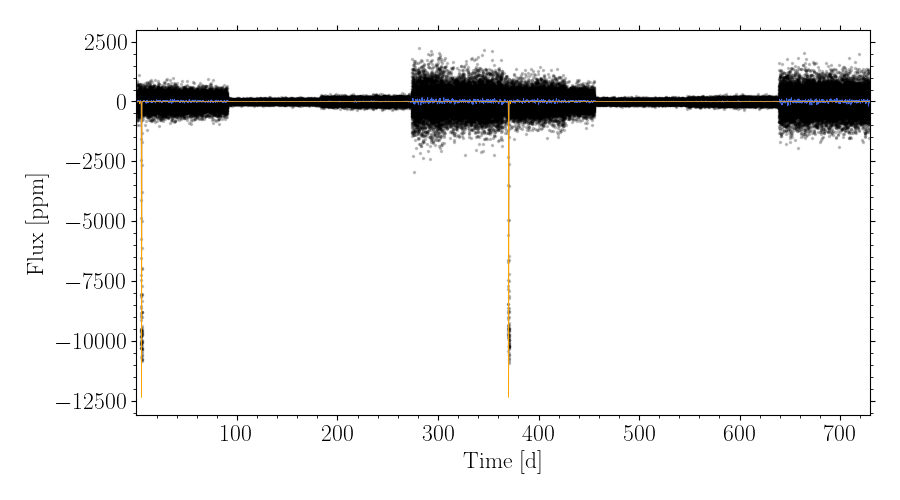

In [94]:
path = '/lhome/nicholas/software/workdir/cs-exomoon/finals'
star = 'mag085/lc_000000005.ftr'
star = 'star5/lc_000000005.ftr'

# In multi mode we parse the entire directory of files
lc = LightCurve(f'{path}/{star}', mode="final")

# Introduce gaps from file
# inputFileGap = '/lhome/nicholas/software/workdir/mocka/input/instrumentGAP.ftr'
# lc.gaps(inputFileGap, replace=True, plot=False);

# Show a quarter light curve
lc.plot(flux_unit='ppm', median_filter=1, input_model=True, legend=False, figsize=(9,5));